In [114]:
import torch
import torch.nn as nn
import torch.optim as optimizer
from torch.utils.data import Dataset , DataLoader , random_split
import torchvision
from torchvision import datasets , transforms
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix , classification_report

# Loading the Fashion MNINST

In [2]:
data = datasets.FashionMNIST(
    root = 'data',
    train = True,
    download = True,
    transform = transforms.ToTensor()
)
test_data = datasets.FashionMNIST(
    root = 'data',
    train = False,
    download = True,
    transform = transforms.ToTensor()
)
# Split based on the indices
val_size = int(len(data) * 0.2)
train_size = len(data) - val_size
train_data , val_data = random_split(data , [train_size , val_size])

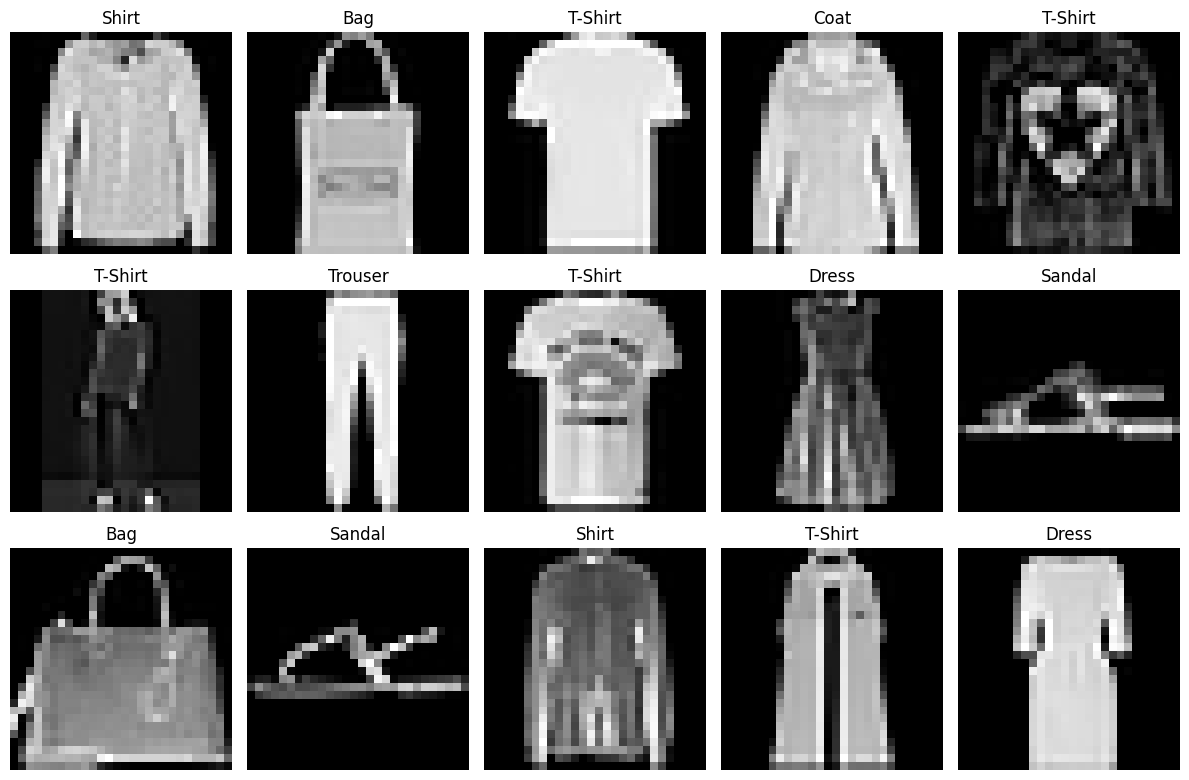

In [113]:

labels_map = {
    0: "T-Shirt", 1: "Trouser", 2: "Pullover", 3: "Dress", 4: "Coat",
    5: "Sandal", 6: "Shirt", 7: "Sneaker", 8: "Bag", 9: "Ankle Boot"
}

def visualize_samples(dataset, num_samples=15):
    plt.figure(figsize=(12, 8))

    for i in range(num_samples):
        idx = torch.randint(len(dataset), size=(1,)).item()
        image, label = dataset[idx]

        plt.subplot(3, 5, i + 1)
        plt.title(labels_map[label])
        plt.axis("off")

        plt.imshow(image.squeeze(), cmap="gray")

    plt.tight_layout()
    plt.show()

visualize_samples(train_data)

In [3]:
train_data.indices[:10]

[21157, 38280, 45826, 20800, 16677, 55605, 54785, 31453, 7341, 33171]

In [7]:
# Select only those rows that are selected for train
train_images = data.data[train_data.indices].reshape((train_size,784))
train_labels = nn.functional.one_hot(data.targets[train_data.indices] , num_classes=10).float()
val_images = data.data[val_data.indices].reshape((val_size,784))
val_labels = nn.functional.one_hot(data.targets[val_data.indices] , num_classes=10).float()
test_images = test_data.data.reshape((10000,784))
test_labels = nn.functional.one_hot(test_data.targets , num_classes=10).float()

In [11]:
print("Train Data")
print(train_images.shape)
print(train_labels.shape)
print("Train Data")
print(val_images.shape)
print(val_labels.shape)
print("Test Data")
print(test_images.shape)
print(test_labels.shape)

Train Data
torch.Size([48000, 784])
torch.Size([48000, 10])
Train Data
torch.Size([12000, 784])
torch.Size([12000, 10])
Test Data
torch.Size([10000, 784])
torch.Size([10000, 10])


# Creating the Custom Dataset class

In [10]:
class FashionMNISTDataset(Dataset):
    def __init__(self, images , labels):
        self.images = images
        self.labels = labels
    def __len__(self):
        return self.images.shape[0]
    def  __getitem__(self,index):
        return self.images[index] / 255 , self.labels[index]


In [12]:
train_dataset = FashionMNISTDataset(train_images , train_labels)
val_dataset = FashionMNISTDataset(val_images , val_labels)
test_dataset = FashionMNISTDataset(test_images , test_labels)

# Main Section

In [72]:
batch_size = 2048
train_batches = DataLoader(train_dataset , batch_size=batch_size,shuffle=True)
val_batches = DataLoader(val_dataset , batch_size=batch_size,shuffle=False)
test_batches = DataLoader(test_dataset , batch_size=batch_size , shuffle=False)

# ANN

In [107]:
class ANN_NN(nn.Module):
    def __init__(self,input_size):
        super().__init__()
        self.out = nn.Sequential(
            nn.Linear(input_size , 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.6),

            nn.Linear(512 , 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(256 , 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(128 , 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(64,32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(32,10)
        )
    def forward(self,x):
        out = self.out(x)
        return out

In [108]:
device = torch.device('cuda')
model = ANN_NN(train_images.shape[1]).to(device)
lr = 0.001
optim = optimizer.Adam(model.parameters() , lr=lr , weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optim, mode='min', factor=0.5, patience=3)

loss_fn = nn.CrossEntropyLoss()
epoch = 100
val_losses = []
train_losses = []
for i in range(epoch):
    model.train()
    pbar  = tqdm(train_batches , desc=f"Training epoch{i+1} / {epoch} " , leave=False)
    train_loss_epoch = 0
    train_acc_epoch = 0
    for images , labels in pbar:
        images = images.to(device)
        labels = labels.to(device)

        out = model(images)
        loss = loss_fn(out , labels)

        acc = (out.argmax(dim=1) == labels.argmax(dim=1)).float().mean()
        train_acc_epoch += acc.item()

        train_loss_epoch += loss.item()
        optim.zero_grad()
        loss.backward()
        optim.step()
        pbar.set_postfix({'loss':loss.item()})
    model.eval()
    val_loss_epoch = 0
    val_acc_epoch = 0
    with torch.no_grad():
        val_pbar = tqdm(val_batches , desc=f"Validation epoch{i+1} / {epoch} " , leave=False)
        for val_images , val_labels in val_pbar:
            val_images = val_images.to(device)
            val_labels = val_labels.to(device)
            val_out = model(val_images)
            val_loss = loss_fn(val_out , val_labels)
            val_loss_epoch += val_loss.item()

            val_acc = (val_out.argmax(dim=1) == val_labels.argmax(dim=1)).float().mean()
            val_acc_epoch += val_acc.item()

            val_pbar.set_postfix({'val_loss':val_loss.item()})
    avg = train_loss_epoch / len(train_batches)
    val_avg = val_loss_epoch / len(val_batches)
    train_acc_avg = train_acc_epoch / len(train_batches)
    val_acc_avg = val_acc_epoch / len(val_batches)
    train_losses.append(avg)
    val_losses.append(val_avg)
    scheduler.step(val_avg)
    print(f"epoch {i+1} : Train loss {avg} , Val loss {val_avg} , Train Accuracy {train_acc_avg*100:.4f} , Val Accuracy {val_acc_avg*100:.4f}")


Training epoch1 / 100 :   0%|          | 0/24 [00:00<?, ?it/s]

Validation epoch1 / 100 :   0%|          | 0/6 [00:00<?, ?it/s]

epoch 1 : Train loss 2.019317756096522 , Val loss 1.7117125789324443 , Train Accuracy 32.4504 , Val Accuracy 59.8704


Training epoch2 / 100 :   0%|          | 0/24 [00:00<?, ?it/s]

Validation epoch2 / 100 :   0%|          | 0/6 [00:00<?, ?it/s]

...

Validation epoch99 / 100 :   0%|          | 0/6 [00:00<?, ?it/s]

epoch 99 : Train loss 0.28966542581717175 , Val loss 0.3036969304084778 , Train Accuracy 91.2717 , Val Accuracy 90.3048


Training epoch100 / 100 :   0%|          | 0/24 [00:00<?, ?it/s]

Validation epoch100 / 100 :   0%|          | 0/6 [00:00<?, ?it/s]

epoch 100 : Train loss 0.294370877246062 , Val loss 0.3034813155730565 , Train Accuracy 91.1592 , Val Accuracy 90.2560


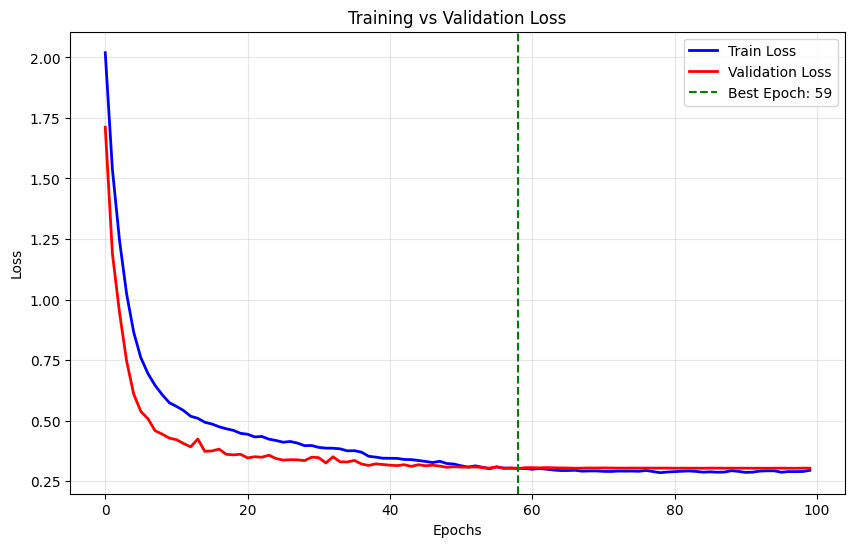

In [109]:

def plot_loss(train_losses, val_losses):
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Train Loss', color='blue', linewidth=2)
    plt.plot(val_losses, label='Validation Loss', color='red', linewidth=2)

    min_val_loss = min(val_losses)
    min_idx = val_losses.index(min_val_loss)
    plt.axvline(x=min_idx, color='green', linestyle='--', label=f'Best Epoch: {min_idx+1}')

    plt.title('Training vs Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_loss(train_losses, val_losses)

# Evaluation

In [110]:
with torch.no_grad():
    test_pbar = tqdm(test_batches , desc="Testing",leave=False)
    acc = 0
    for images , labels in test_pbar:
        images = images.to(device)
        labels = labels.to(device)
        out = model(images)
        acc += (out.argmax(dim=1) == labels.argmax(dim=1)).float().mean()
        test_pbar.set_postfix({'test_acc':acc.item()})
    acc_avg = acc / len(test_batches)
    print(f"Test Accuracy {acc_avg*100:.4f}")

Testing:   0%|          | 0/5 [00:00<?, ?it/s]

Test Accuracy 89.2608


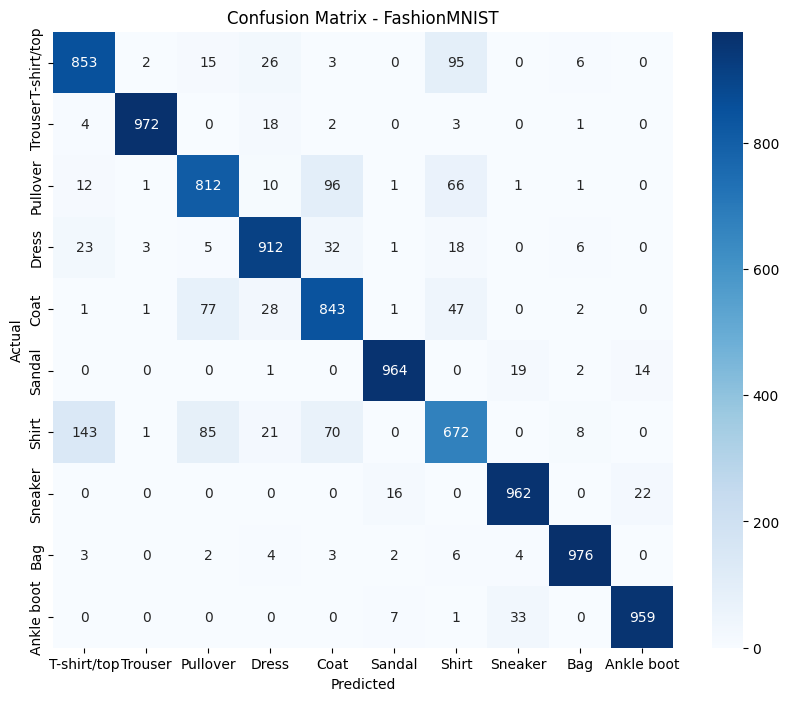

--------------------------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.82      0.85      0.84      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.82      0.81      0.81      1000
       Dress       0.89      0.91      0.90      1000
        Coat       0.80      0.84      0.82      1000
      Sandal       0.97      0.96      0.97      1000
       Shirt       0.74      0.67      0.70      1000
     Sneaker       0.94      0.96      0.95      1000
         Bag       0.97      0.98      0.98      1000
  Ankle boot       0.96      0.96      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

Per-Class Accuracy:
T-shirt/top: 85.30%
Trouser: 97.20%
Pullover: 81.20%
Dress: 91.20%
Coat: 84.30%
Sandal: 96.40%
Shirt: 67.20%
Sneaker:

In [111]:
def evaluate_model(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            labels = torch.argmax(labels, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes,
                yticklabels=classes)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix - FashionMNIST")
    plt.show()

    print("--"*40)
    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=classes))
    class_accuracy = cm.diagonal() / cm.sum(axis=1)

    print("Per-Class Accuracy:")
    for idx, acc in enumerate(class_accuracy):
        print(f"{classes[idx]}: {acc*100:.2f}%")
    overall_acc = np.sum(cm.diagonal()) / np.sum(cm)
    print(f"Overall Accuracy: {overall_acc*100:.2f}%")

evaluate_model(model, test_batches, device)